<a href="https://colab.research.google.com/github/devpatel0005/Stock-Sentiment-Analysis-based-on-News/blob/main/Stock_Sentiment_Analysis_Using_LSTM_based_on_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- The data set in consideration is a combination of the world news and stock price shifts available on Kaggle.
- There are 25 columns of top news headlines for each day in the data frame.
Data ranges from 2008 to 2016 and the data from 2000 to 2008 was scrapped from Yahoo finance.
- Labels are based on the Dow Jones Industrial Average stock index.
- Class 1 → the stock price increased.
- Class 0 → the stock price stayed the same or decreased.

In [1]:
import pandas as pd
df=pd.read_csv('/content/Data.csv',encoding='ISO-8859-1')

df.sample(5)

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
1690,2006-12-04,0,Two killed in fireworks factory fire,"Ennio Morricone, Hammersmith Apollo, London","Das Rheingold, Millennium Centre, Cardiff","Dionne Warwick, Shaw Theatre, London",Knight Frank staff share £32m pot as property ...,The Ashes: England impress channel 9,The Ashes: Mike Selvey on the third day's play,The Ashes: Day three analysis,...,Rallying: Gronholm targets title,Rugby Union: EDF Energy Cup: Sale 21 - 5 Llanelli,Athletics: Gebrselassie claims Fukuoka marathon,Businesslike Ponting sees stock keep rising,Horse Racing: Clopf hides at Fairyhouse,Organ grinder,The latest news on propaganda,Dispatches,Solve IT,"Who'd be a boss? I mean, it's just not worth t..."
2742,2011-02-08,1,The Church of Scientology is Under Investigati...,Shocking 'Egypt images' emerge - Middle East -...,Louis Theroux: The Ultra Zionists,Egyptian President Hosni Mubarak may be the wo...,The Last POW - story of a Japanese man who has...,Wikileaks Releases Cables On Egypt VP Omar Sul...,"6000 Workers Sit In, As The First Suez Canal S...",Mass demonstrations continue in Cairo: The rel...,...,Egyptian Ex-Interior Minister Habib el-Adly un...,Egypt's new VP Suleiman: The CIA's man in Cairo,Normally cited as an example of good governanc...,Scientology fury at FBI probe,Al Jazeera English correspondent reports on hi...,"Wael Ghonim, one of the instigators of the Jan...",Violence against medical staff and increased l...,Still No Water Or Electricity In Iraq 8 Years ...,Wael Ghonim DreamTV interview playlist - part ...,Blogger's release 'reignites' Egypt - Middle E...
1663,2006-10-25,1,Whatever happened to West Ham's stars of last ...,Noble puts his faith in debutants,Horse racing: O'Brien nails colours to a $5m mast,Business of sport: Stakes raised in battle of ...,Horse racing: Ascot going sets punters a firm ...,Golf: Howell's shoulder may hand Casey Europea...,Golf: Teenager Matharu ready to test herself,Cycling: London's Tour fanfare overshadowed by...,...,Digger: Reedie cannot go to the ball,Marina Hyde: FA long in tooth but short on wisdom,Carling Cup: Liverpool 4 - 3 Reading,Carling Cup: Newcastle 3 - 0 Portsmouth,Carling Cup: Crewe 1 - 2 Man Utd,Carling Cup: Charlton 1 Bolton 0,Carling Cup: MK Dons 0 - 5 Spurs,Carling Cup: Blackburn 0 - 2 Chelsea,FA chairman braced for defeat over Burns reform,FA probes Israeli club over Ben Haim transfer
5,2000-01-10,1,Fifth round draw,BBC unveils secret weapon in ratings war: Sout...,Second Division round-up,European round-up,Third Division round-up,Welfare could claim Killie tie as Caley Thistl...,Ferguson puts brave face on Rio meltdown,Southgate in striking form to pre-empt penalties,...,Time Warner and AOL to merge,Keep up,Waging global war,"Desktop icons, No 1: The Qwerty keyboard",The sec's files,The low down: Workplace bullying,Met 'not equipped' to solve murders,Tranmere tie will not be replayed,Rebel attacks take toll on Russia,Met lent stopped car to Lawrence
2390,2009-09-16,1,"b""Europe now richer than America: North Americ...",b'The ORIGINAL execution video of Sri Lankan s...,b'Banana sex cult leader splits after raid',"b'New UN Report Released Today: ""The Israeli m...",b'A UN mission concludes that war crimes were ...,b'IAEA Conceals Evidence Iran Nuclear Document...,"b""Israel readies for diplomatic war over 'bias...","b""Israel moves to discredit 'war crimes' report""",...,b'Human Rights Watch analyst suspended over Na...,b'U.S. raid in Somalia could win valuable inte...,"b'UK motorists with uninsured cars face 1,000 ...",b'Change we can believe in: Obama fulfilling h...,"b""Nepal's capital city, Kathmandu, has run out...",b'Argentine Government Fast-Tracking Controver...,b'EU farmers in white heat over milk prices',b'Cuban police arrest editor of independent di...,b'Damn it CNN if your are going to cover a pre...,b'Unable to voice their opposition in the stre...


- ISO-8859-1, also known as Latin-1, is a character encoding standard that maps 256 different characters to numerical values. It's one of the most common encodings used for text in Western European languages

In [2]:
df.shape

(4101, 27)

# Splitting the Data into train and test

In [3]:
df['Date']

,Date
0,2000-01-03
1,2000-01-04
2,2000-01-05
3,2000-01-06
4,2000-01-07
...,...
4096,2016-06-27
4097,2016-06-28
4098,2016-06-29
4099,2016-06-30


In [13]:
train=df[df['Date']<'20150101']
test=df[df['Date']>'20141231']

In [14]:
test.shape

(378, 27)

In [15]:
train.shape

(3975, 27)

# Feature Engineering


In [16]:
data=train.iloc[:,2:27]
data.replace('[^a-zA-Z]',' ',regex=True,inplace=True) #replace the full stop punctuattion with space

#renaming the columns for ease of acess
new_index=[str(i) for i in range(25)] #since our data has 25 columns top 25 news headlines for stock
data.columns=new_index

In [17]:
data

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,A hindrance to operations extracts from the...,Scorecard,Hughes instant hit buoys Blues,Jack gets his skates on at ice cold Alex,Chaos as Maracana builds up for United,Depleted Leicester prevail as Elliott spoils E...,Hungry Spurs sense rich pickings,Gunners so wide of an easy target,Derby raise a glass to Strupar s debut double,Southgate strikes Leeds pay the penalty,...,Flintoff injury piles on woe for England,Hunters threaten Jospin with new battle of the...,Kohl s successor drawn into scandal,The difference between men and women,Sara Denver nurse turned solicitor,Diana s landmine crusade put Tories in a panic,Yeltsin s resignation caught opposition flat f...,Russian roulette,Sold out,Recovering a title
1,Scorecard,The best lake scene,Leader German sleaze inquiry,Cheerio boyo,The main recommendations,Has Cubie killed fees,Has Cubie killed fees,Has Cubie killed fees,Hopkins furious at Foster s lack of Hannibal...,Has Cubie killed fees,...,On the critical list,The timing of their lives,Dear doctor,Irish court halts IRA man s extradition to Nor...,Burundi peace initiative fades after rebels re...,PE points the way forward to the ECB,Campaigners keep up pressure on Nazi war crime...,Jane Ratcliffe,Yet more things you wouldn t know without the ...,Millennium bug fails to bite
2,Coventry caught on counter by Flo,United s rivals on the road to Rio,Thatcher issues defence before trial by video,Police help Smith lay down the law at Everton,Tale of Trautmann bears two more retellings,England on the rack,Pakistan retaliate with call for video of Walsh,Cullinan continues his Cape monopoly,McGrath puts India out of their misery,Blair Witch bandwagon rolls on,...,South Melbourne Australia,Necaxa Mexico,Real Madrid Spain,Raja Casablanca Morocco,Corinthians Brazil,Tony s pet project,Al Nassr Saudi Arabia,Ideal Holmes show,Pinochet leaves hospital after tests,Useful links
3,Pilgrim knows how to progress,Thatcher facing ban,McIlroy calls for Irish fighting spirit,Leicester bin stadium blueprint,United braced for Mexican wave,Auntie back in fashion even if the dress look...,Shoaib appeal goes to the top,Hussain hurt by shambles but lays blame on e...,England s decade of disasters,Revenge is sweet for jubilant Cronje,...,Putin admits Yeltsin quit to give him a head s...,BBC worst hit as digital TV begins to bite,How much can you pay for,Christmas glitches,Upending a table Chopping a line and Scoring ...,Scientific evidence unreliable defence claims,Fusco wins judicial review in extradition case,Rebels thwart Russian advance,Blair orders shake up of failing NHS,Lessons of law s hard heart
4,Hitches and Horlocks,Beckham off but United survive,Breast cancer screening,Alan Parker,Guardian readers are you all whingers,Hollywood Beyond,Ashes and diamonds,Whingers a formidable minority,Alan Parker part two,Thuggery Toxins and Ties,...,Most everywhere UDIs,Most wanted Chloe lunettes,Return of the cane completely off the agenda,From Sleepy Hollow to Greeneland,Blunkett outlines vision for over s,Embattled Dobson attacks play now pay later ...,Doom and the Dome,What is the north south divide,Aitken released from jail,Gone aloft
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3970,Brazil declares emergency after babies a...,Scientists find big yr old Viking settlem...,Paris attacks Belgian police arrest ninth sus...,Wiretapping reveals communication between Turk...,Russia airstrikes Hundreds of Syrian civilans...,Pakistan changes neutral position on Syrian Ci...,North Korean diplomat arrested in South Africa...,German teachers want Mein Kampf on syllabus,North Korea slave force earns Kim Jong Un regi...,Yemeni Forces Preparing to Attack Saudi...,...,Report on sexual exploitation and abuse by pea...,Baby girl dies after X president s son s staff...,China smog sparks red alerts in cities,US planned East Berlin s systematic destructi...,Qatar World Cup workers e

# Converting the headlines into lowercase

In [18]:
for index in new_index:
  data[index]=data[index].str.lower()

In [19]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,a hindrance to operations extracts from the...,scorecard,hughes instant hit buoys blues,jack gets his skates on at ice cold alex,chaos as maracana builds up for united,depleted leicester prevail as elliott spoils e...,hungry spurs sense rich pickings,gunners so wide of an easy target,derby raise a glass to strupar s debut double,southgate strikes leeds pay the penalty,...,flintoff injury piles on woe for england,hunters threaten jospin with new battle of the...,kohl s successor drawn into scandal,the difference between men and women,sara denver nurse turned solicitor,diana s landmine crusade put tories in a panic,yeltsin s resignation caught opposition flat f...,russian roulette,sold out,recovering a title
1,scorecard,the best lake scene,leader german sleaze inquiry,cheerio boyo,the main recommendations,has cubie killed fees,has cubie killed fees,has cubie killed fees,hopkins furious at foster s lack of hannibal...,has cubie killed fees,...,on the critical list,the timing of their lives,dear doctor,irish court halts ira man s extradition to nor...,burundi peace initiative fades after rebels re...,pe points the way forward to the ecb,campaigners keep up pressure on nazi war crime...,jane ratcliffe,yet more things you wouldn t know without the ...,millennium bug fails to bite
2,coventry caught on counter by flo,united s rivals on the road to rio,thatcher issues defence before trial by video,police help smith lay down the law at everton,tale of trautmann bears two more retellings,england on the rack,pakistan retaliate with call for video of walsh,cullinan continues his cape monopoly,mcgrath puts india out of their misery,blair witch bandwagon rolls on,...,south melbourne australia,necaxa mexico,real madrid spain,raja casablanca morocco,corinthians brazil,tony s pet project,al nassr saudi arabia,ideal holmes show,pinochet leaves hospital after tests,useful links
3,pilgrim knows how to progress,thatcher facing ban,mcilroy calls for irish fighting spirit,leicester bin stadium blueprint,united braced for mexican wave,auntie back in fashion even if the dress look...,shoaib appeal goes to the top,hussain hurt by shambles but lays blame on e...,england s decade of disasters,revenge is sweet for jubilant cronje,...,putin admits yeltsin quit to give him a head s...,bbc worst hit as digital tv begins to bite,how much can you pay for,christmas glitches,upending a table chopping a line and scoring ...,scientific evidence unreliable defence claims,fusco wins judicial review in extradition case,rebels thwart russian advance,blair orders shake up of failing nhs,lessons of law s hard heart
4,hitches and horlocks,beckham off but united survive,breast cancer screening,alan parker,guardian readers are you all whingers,hollywood beyond,ashes and diamonds,whingers a formidable minority,alan parker part two,thuggery toxins and ties,...,most everywhere udis,most wanted chloe lunettes,return of the cane completely off the agenda,from sleepy hollow to greeneland,blunkett outlines vision for over s,embattled dobson attacks play now pay later ...,doom and the dome,what is the north south divide,aitken released from jail,gone aloft


- Now for implementing the NLP techniques like Bag of Words or Tf-IDF we need to combine these all columns of a row into one single paragraph for every row

In [20]:
data.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       3965, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974],
      dtype='int64', length=3975)

In [21]:
headlines=[]
for rows in range(0,len(data.index)):
  headlines.append(' '.join(str(x) for x in data.iloc[rows,0:25])) # columns are from 0 to 24 so we mentioned 0:25 to include all

In [22]:
headlines[1]

'scorecard the best lake scene leader  german sleaze inquiry cheerio  boyo the main recommendations has cubie killed fees  has cubie killed fees  has cubie killed fees  hopkins  furious  at foster s lack of hannibal appetite has cubie killed fees  a tale of two tails i say what i like and i like what i say elbows  eyes and nipples task force to assess risk of asteroid collision how i found myself at last on the critical list the timing of their lives dear doctor irish court halts ira man s extradition to northern ireland burundi peace initiative fades after rebels reject mandela as mediator pe points the way forward to the ecb campaigners keep up pressure on nazi war crimes suspect jane ratcliffe yet more things you wouldn t know without the movies millennium bug fails to bite'

- Now for every row we have merged  of each and every index the news into one single headline

In [23]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.7 MB/s eta 0:00:00


In [24]:
import nltk
from gensim.models import Word2Vec
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [25]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
"""
lematized_headlines=[]
for paragraph in headlines:
  sentences=nltk.sent_tokenize(paragraph)
  for i in range(len(sentences)):
    text=[word for word in sentences[i] if word not in stopwords.words('english') ]
    text=' '.join(text)
  lematized_headlines.append(text)
"""

"\nlematized_headlines=[]\nfor paragraph in headlines:\n  sentences=nltk.sent_tokenize(paragraph)\n  for i in range(len(sentences)):\n    text=[word for word in sentences[i] if word not in stopwords.words('english') ]\n    text=' '.join(text)\n  lematized_headlines.append(text)\n"

- TF-IDF produces a single, large, sparse vector for the entire message (e.g., a vector of size 5000 where most values are 0). It completely destroys the word order.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
training_data=tfidf.fit_transform(headlines).toarray()

In [27]:
training_data.shape

(3975, 46002)

- Now preparing test data

In [28]:
test_transform=[]
for row in range(0,len(test.index)):
    test_transform.append(' '.join(str(x) for x in test.iloc[row,2:27]))
test_data=tfidf.transform(test_transform).toarray()

In [29]:
test_data.shape

(378, 46002)

In [30]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier model
# Using n_estimators=200 for a robust model, you can adjust this parameter.
randomforest_classifier = RandomForestClassifier(n_estimators=200, criterion='entropy')

# Train the classifiers
randomforest_classifier.fit(training_data, train['Label'])


RandomForestClassifier(criterion='entropy', n_estimators=200)

In [31]:
predictions = randomforest_classifier.predict(test_data)

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Get true labels for the test set
y_true = test['Label']

# Evaluate the model
print("Classification Report:")
print(classification_report(y_true, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_true, predictions))

print("Accuracy Score:")
print(accuracy_score(y_true, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82       186
           1       0.79      0.92      0.85       192

    accuracy                           0.84       378
   macro avg       0.85      0.83      0.83       378
weighted avg       0.85      0.84      0.83       378

Confusion Matrix:
[[139  47]
 [ 15 177]]
Accuracy Score:
0.8359788359788359


In [38]:
training_data.shape

(3975, 46002)

# LSTM Implementation

In [99]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from keras.optimizers import Adam
from tensorflow.keras.layers import Dense,Embedding,Dropout,BatchNormalization,LSTM

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val=train_test_split(training_data,train['Label'],random_state=42,test_size=0.1)

In [49]:
x_train.shape

(3577, 46002)

In [116]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,Dropout,BatchNormalization,LSTM, Input, Reshape, Bidirectional # Added Bidirectional
from tensorflow.keras.regularizers import l2 # Import l2 regularizer

tf.keras.backend.clear_session()

model=Sequential()
# Use an Input layer for the original 2D TF-IDF input shape
model.add(Input(shape=(x_train.shape[1],)))
# Reshape to (batch_size, timesteps, features), where timesteps=1
model.add(Reshape((1, x_train.shape[1])))
# Using Bidirectional LSTM layers
model.add(Bidirectional(LSTM(128, activation='relu', return_sequences=True,kernel_regularizer=l2(0.01))))
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(64, activation='relu', return_sequences=True,kernel_regularizer=l2(0.01)))) # Keep return_sequences=True for stacking another BiLSTM
model.add(Dropout(0.2))
model.add(Bidirectional(LSTM(32, activation='relu',kernel_regularizer=l2(0.01))))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))

In [117]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 1, 46002)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │    47,238,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1, 128)         │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,443,777 (180.98 MB)

 Trainable params: 47,443,777 (180.98 MB)

 Non-trainable params: 0 (0.00 B)

In [118]:
model.compile(optimizer=Adam(0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [119]:
history=model.fit(x_train,y_train,epochs=20,validation_data=(x_val,y_val),batch_size=32)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.5270 - loss: 7.9038 - val_accuracy: 0.5226 - val_loss: 0.9506
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5299 - loss: 0.8242 - val_accuracy: 0.5226 - val_loss: 0.6977
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5343 - loss: 0.6940 - val_accuracy: 0.5226 - val_loss: 0.6922
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5294 - loss: 0.6916 - val_accuracy: 0.5226 - val_loss: 0.6921
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5299 - loss: 0.6915 - val_accuracy: 0.5226 - val_loss: 0.6921
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5215 - loss: 0.6923 - val_accuracy: 0.5226 - val_loss: 0.6922
Epoch 7/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5234 - loss: 0.6921 - val_accuracy: 0.5226 - val_loss: 0.6922
Epoch 8/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5395 - loss: 0.6904 - val_acc

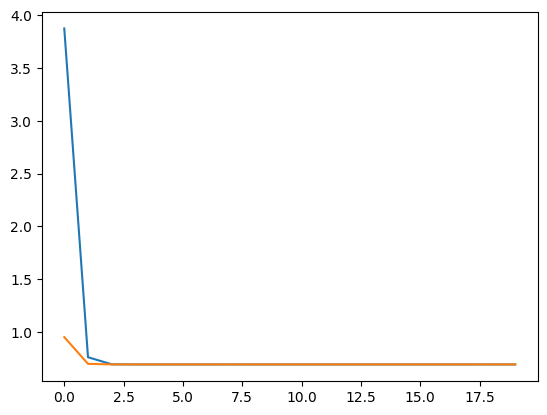

In [120]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
